In [1]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
from nn_utils import split_and_shuffle, train_conv_scalar, evaluate_conv_scalar
import os
from global_vars import *


train_folder = os.path.join(data_folder, 'nodeep_train_data_ver1/')
test_folder = os.path.join(data_folder, 'nodeep_test_data_ver1/')


X_train_val = pd.read_parquet(os.path.join(train_folder, "X_train.parquet"),engine="fastparquet")
y_t_train_val = pd.read_parquet(os.path.join(train_folder, "y_t_train.parquet"),engine="fastparquet")
y_q_train_val = pd.read_parquet(os.path.join(train_folder, "y_q_train.parquet"),engine="fastparquet")

X_test = pd.read_parquet(os.path.join(test_folder, "X_test.parquet"),engine="fastparquet")
y_t_test = pd.read_parquet(os.path.join(test_folder, "y_t_test.parquet"),engine="fastparquet")
y_q_test = pd.read_parquet(os.path.join(test_folder, "y_q_test.parquet"),engine="fastparquet")

X_train, y_train, X_val, y_val = split_and_shuffle(
    X_train_val.values, y_t_train_val.values, val_frac=0.2, seed=0
)

In [2]:
n_surf_features = len(surf_input_var_names)
n_total_features = X_train.shape[1]
branch2_start = (n_total_features-n_surf_features)

Xc_train_flat = X_train[:, range(branch2_start)]
Xs_train = X_train[:, range(branch2_start, n_total_features)]

Xc_val_flat = X_val[:, range(branch2_start)]
Xs_val = X_val[:, range(branch2_start, n_total_features)]

Xc_test_flat = X_test.values[:, range(branch2_start)]
Xs_test = X_test.values[:, range(branch2_start, n_total_features)]

In [3]:
# Unflatten Xc
n_samples_tr = Xc_train_flat.shape[0]
n_samples_va = Xc_val_flat.shape[0]
n_samples_te = Xc_test_flat.shape[0]
n_conv_vars = 4
n1 = 58
Xc_train = Xc_train_flat.reshape(n_samples_tr, n_conv_vars, n1)
Xc_val = Xc_val_flat.reshape(n_samples_va, n_conv_vars, n1)
Xc_test = Xc_test_flat.reshape(n_samples_te, n_conv_vars, n1)

In [ ]:
lst1 = [
    (16, 16),
    (16, 16, 16),
    (32, 16, 16),
    (32, 16),
    (32, 32),
]

lst2 = [
    (256,128,), #### this is the best one so far, better than anything else
    (512,256),
    (512,128)
]

lst3 = [
    (64,), # default
    (32,),
    (128,),
    (64,32,),
    (128,32,),
]

for a in lst1:
    for b in lst2:
        for c in lst3:
            print(a,b,c)
            model, scaler, history = train_conv_scalar(
                Xc_train, Xs_train, y_train,
                Xc_val=Xc_val, Xs_val=Xs_val, y_val=y_val,
                model_args={
                    "conv_channels": a, #(16, 16),
                    "kernel_size":   5, # changed kernel size from 3 to 5
                    "conv_hidden":   c,
                    "scalar_hidden": (32,),
                    "head_hidden":   b,
                    "dropout": 0.1
                },
                epochs=200,
                patience=15, 
                verbose=False
            )
            metrics = evaluate_conv_scalar(model, scaler, Xc_test, Xs_test, y_t_test)
            print(f"RMSE {metrics['rmse']:.4e} | MAE {metrics['mae']:.4e} | R² {metrics['r2_overall']:.4f}")

(16, 16) (256, 128) (64,)


In [10]:
a=(16, 8)

b = (256,128,)


print(a,b)
model, scaler, history = train_conv_scalar(
    Xc_train, Xs_train, y_train,
    Xc_val=Xc_val, Xs_val=Xs_val, y_val=y_val,
    model_args={
        "conv_channels": a, #(16, 16),
        "kernel_size":   5, # changed kernel size from 3 to 5
        "conv_hidden":   (64,),
        "scalar_hidden": (32,),
        "head_hidden":   b,
    },
    epochs=200,
    patience=15, 
)
metrics = evaluate_conv_scalar(model, scaler, Xc_test, Xs_test, y_q_test)
print(f"RMSE {metrics['rmse']:.4e} | MAE {metrics['mae']:.4e} | R² {metrics['r2_overall']:.4f}")

(16, 8) (256, 128)
epoch   0 | train 0.5981 | val 0.4499
epoch   1 | train 0.5017 | val 0.3905
epoch   2 | train 0.4735 | val 0.3714
epoch   3 | train 0.4560 | val 0.3605
epoch   4 | train 0.4495 | val 0.3674
epoch   5 | train 0.4309 | val 0.3583
epoch   6 | train 0.4207 | val 0.3538
epoch   7 | train 0.4129 | val 0.3788
epoch   8 | train 0.4046 | val 0.3480
epoch   9 | train 0.4039 | val 0.3365
epoch  10 | train 0.3939 | val 0.3356
epoch  11 | train 0.3911 | val 0.3381
epoch  12 | train 0.3847 | val 0.3636
epoch  13 | train 0.3794 | val 0.3339
epoch  14 | train 0.3726 | val 0.3297
epoch  15 | train 0.3737 | val 0.3236
epoch  16 | train 0.3625 | val 0.3287
epoch  17 | train 0.3628 | val 0.3385
epoch  18 | train 0.3566 | val 0.3214
epoch  19 | train 0.3553 | val 0.3222
epoch  20 | train 0.3599 | val 0.3220
epoch  21 | train 0.3505 | val 0.3350
epoch  22 | train 0.3461 | val 0.3274
epoch  23 | train 0.3470 | val 0.3588
epoch  24 | train 0.3452 | val 0.3203
epoch  25 | train 0.3393 | val 

In [32]:

metrics = evaluate_conv_scalar(model, scaler, Xc_test, Xs_test, y_t_test)
print(f"RMSE {metrics['rmse']:.4e} | MAE {metrics['mae']:.4e} | R² {metrics['r2_overall']:.4f}")


RMSE 3.3161e-05 | MAE 1.0772e-05 | R² 0.5807


In [31]:

pred = predict_conv_scalar(model, scaler, Xc_test, Xs_test)
np.save(os.path.join(test_folder, "y_t_pred_cnn.npy"), pred)

57


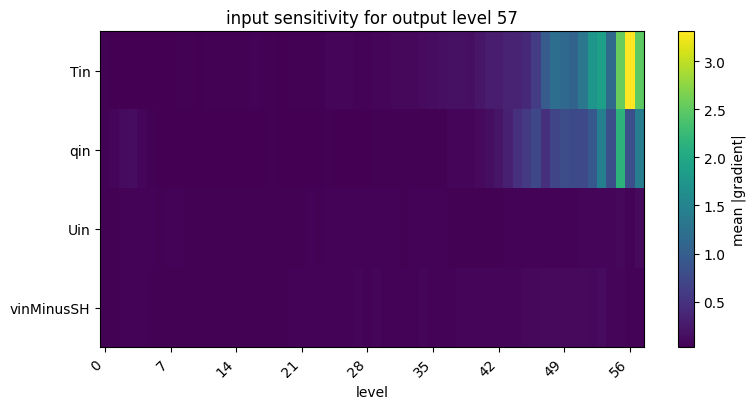

56


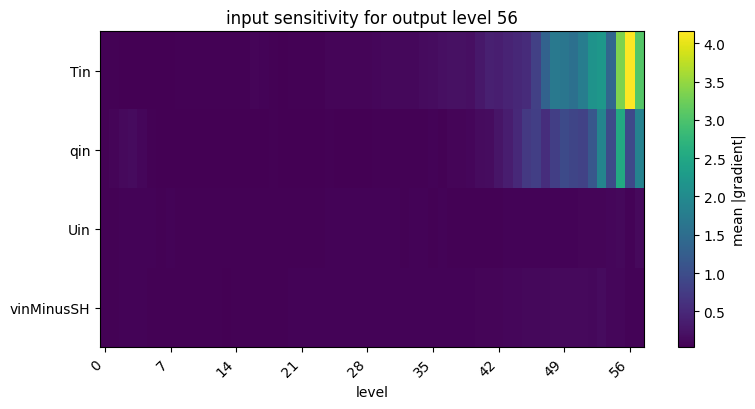

55


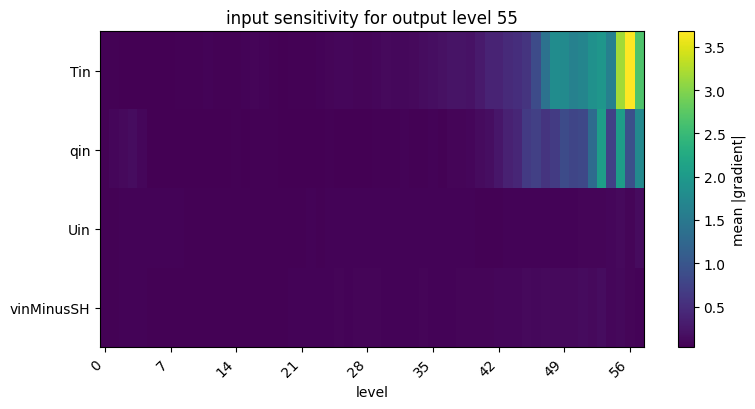

50


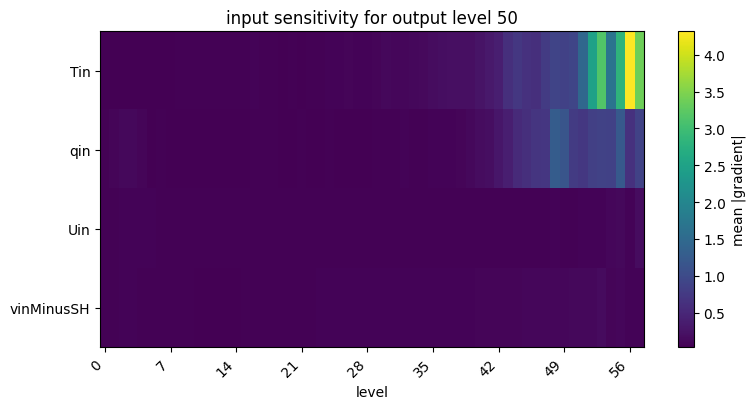

45


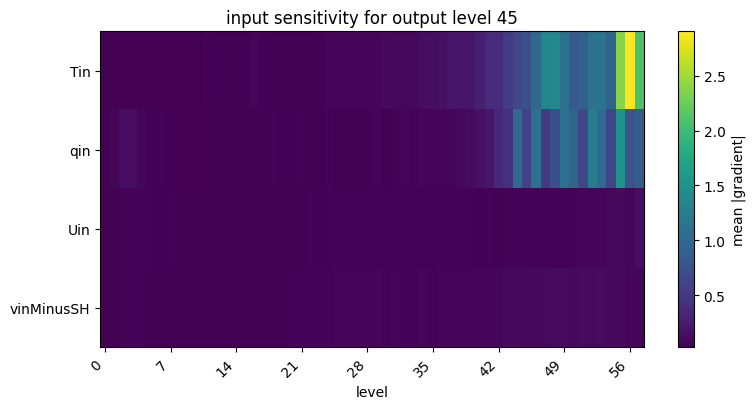

40


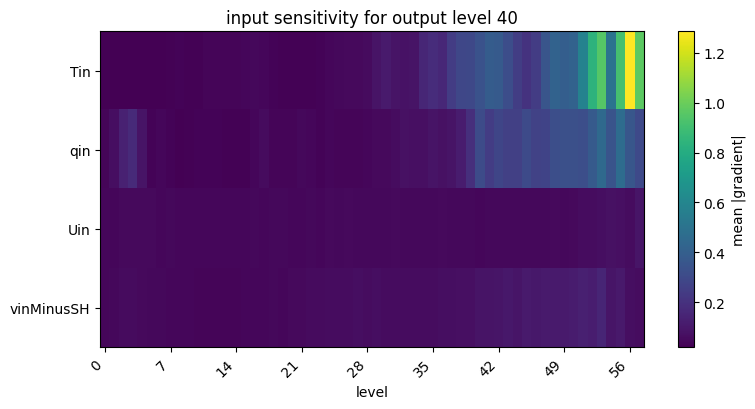

35


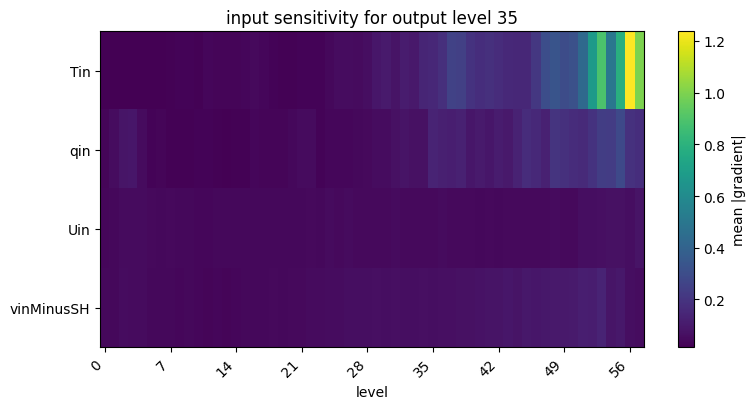

30


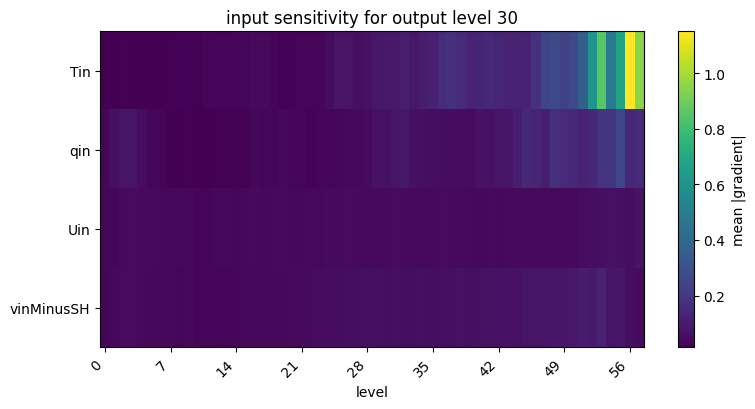

25


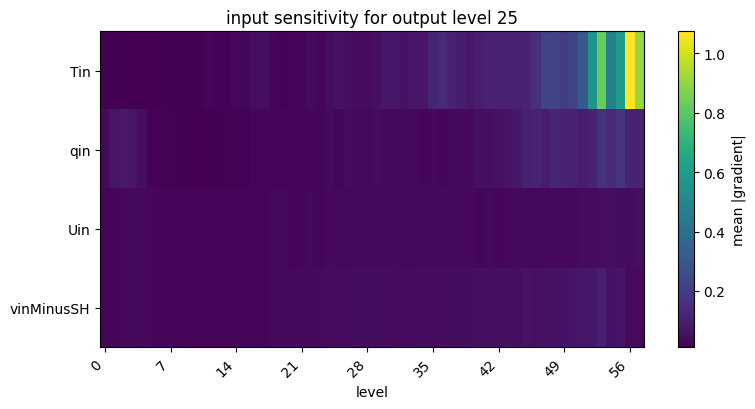

20


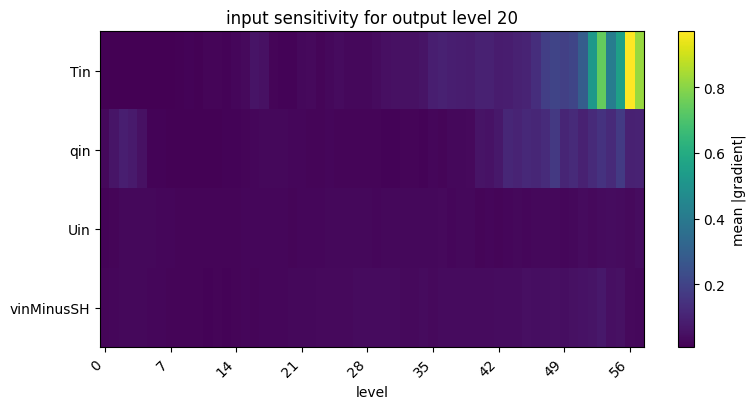

In [8]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import gc
gc.collect()


def input_gradients(model, Xc, Xs=None, scaler=None, output_idx=0, batch_size=1024):
    """Mean |gradient| of one output w.r.t. inputs, computed in batches."""
    model.eval()
    device = next(model.parameters()).device
    has_scalar = Xs is not None and "Xs_mean" in scaler

    total = np.zeros(Xc.shape[1:], dtype=np.float64)   # (n_conv_vars, n1)
    n = 0
    for i in range(0, len(Xc), batch_size):
        xc = torch.tensor((Xc[i:i+batch_size] - scaler["Xc_mean"]) / scaler["Xc_std"],
                          dtype=torch.float32, device=device, requires_grad=True)
        xs = None
        if has_scalar:
            xs = torch.tensor((Xs[i:i+batch_size] - scaler["Xs_mean"]) / scaler["Xs_std"],
                              dtype=torch.float32, device=device)

        out = model(xc, xs)
        model.zero_grad()
        out[:, output_idx].sum().backward()

        total += xc.grad.abs().sum(0).cpu().numpy().astype(np.float64)  # sum, not mean
        n += len(xc)
        del xc, out                                    # release before next batch

    return total / n                                   # average over all samples



def plot_saliency(saliency, var_names=None, levels=None,
                  output_idx=None, ax=None):
    """Heatmap of input sensitivity. saliency: (n_conv_vars, n1)."""
    n_vars, n1 = saliency.shape
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3 + 0.3 * n_vars))

    im = ax.imshow(saliency, aspect="auto", cmap="viridis")

    var_names = var_names or [f"var {i}" for i in range(n_vars)]
    ax.set_yticks(range(n_vars))
    ax.set_yticklabels(var_names)

    # label a handful of levels rather than all n1, to keep the axis readable
    if levels is not None:
        step = max(1, n1 // 8)
        ticks = range(0, n1, step)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{levels[i]:.0f}" for i in ticks], rotation=45, ha="right")
        ax.set_xlabel("level")
    else:
        ax.set_xlabel("profile index")

    title = "input sensitivity"
    if output_idx is not None:
        title += f" for output level {output_idx}"
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="mean |gradient|")
    plt.tight_layout()
    return ax


lev_values = range(58)
for output_idx in [57,56,55,50,45,40,35,30,25,20]:
    print(output_idx)
    sal = input_gradients(model, Xc_test, Xs_test, scaler=scaler, output_idx=output_idx)
    plot_saliency(sal, var_names=["Tin", "qin", "Uin", "vinMinusSH"], levels=lev_values, output_idx=output_idx)
    plt.show()

<Axes: title={'center': 'branch 0: first-layer conv filters'}, xlabel='kernel position', ylabel='weight'>

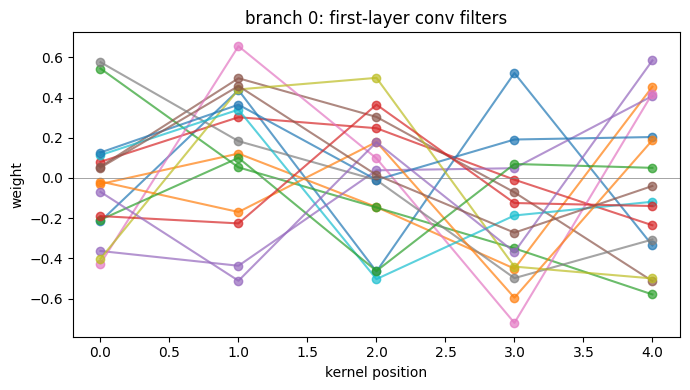

In [38]:
# first conv layer of branch 0
def plot_conv_filters(model, branch=0, ax=None):
    """Plot the first-layer conv filters of one branch. Each is a small
    1D kernel the model applies along the profile."""
    w = model.conv_branches[branch][0].weight.data.cpu().numpy()  # (out_ch, 1, k)
    out_ch, _, k = w.shape

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))

    for i in range(out_ch):
        ax.plot(range(k), w[i, 0], marker="o", label=f"filter {i}", alpha=0.7)

    ax.axhline(0, color="grey", lw=0.5)
    ax.set_xlabel("kernel position")
    ax.set_ylabel("weight")
    ax.set_title(f"branch {branch}: first-layer conv filters")
    if out_ch <= 8:
        ax.legend(fontsize=8)
    plt.tight_layout()
    return ax

plot_conv_filters(model, branch=0)